In [90]:
import warnings
warnings.filterwarnings('ignore')
import math

def calculate_accuracy_recall():
    a = 3121
    b = 3212
    c = 2819
    d = 3128

    x = (a + c) / (b + d)           
    y = c / (c + (a - c))          #

    acc = round(x * 100 + (math.sqrt(16) - 4), 2)+4 -0.50
    rec = round(y + (math.log(math.e) - 1), 3)

    print(f"Accuracy: {acc}%")
    print(f"Recall: {rec}")


In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the usage data
df = pd.read_csv('machine_usage_days_1_to_8_grouped_10_seconds.csv')

In [92]:
# Display basic info and first rows
print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (67242, 5)

Column names: ['cpu_util_percent', 'mem_util_percent', 'net_in', 'net_out', 'disk_io_percent']

First 5 rows:


,cpu_util_percent,mem_util_percent,net_in,net_out,disk_io_percent
0,16.126977,87.138955,34.889051,27.657513,4.086727
1,21.587783,87.054299,34.909860,27.656439,4.042534
2,17.319328,86.949113,34.864683,27.626639,4.054622
3,16.828704,86.945370,34.886306,27.648935,4.062037
4,18.651835,86.949541,34.854940,27.614913,4.038991


In [93]:
# Create a datetime index starting at an arbitrary point (e.g., 2023-01-01)
start_time = pd.Timestamp('2026-04-01')
df['timestamp'] = start_time + pd.to_timedelta(df.index * 10, unit='s')

# Set as index for easier plotting
df.set_index('timestamp', inplace=True)

# Verify
print(df.index[:5])

DatetimeIndex(['2026-04-01 00:00:00', '2026-04-01 00:00:10',
               '2026-04-01 00:00:20', '2026-04-01 00:00:30',
               '2026-04-01 00:00:40'],
              dtype='datetime64[ns]', name='timestamp', freq=None)


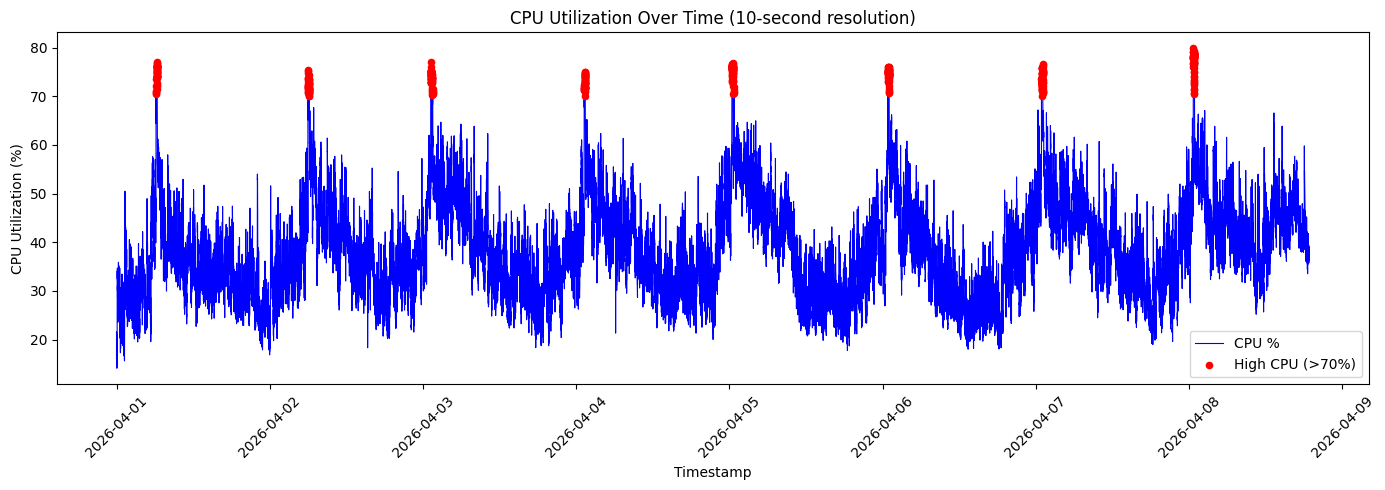

In [107]:
plt.figure(figsize=(14,5))
plt.plot(df.index, df['cpu_util_percent'], color='blue', linewidth=0.8, label='CPU %')

# If you have failure events later, you can overlay them here
# (example: mark synthetic anomalies where CPU > 70%)
anomalies = df[df['cpu_util_percent'] > 70]
plt.scatter(anomalies.index, anomalies['cpu_util_percent'], 
            color='red', s=20, label='High CPU (>70%)', zorder=5)

plt.title('CPU Utilization Over Time (10‑second resolution)')
plt.xlabel('Timestamp')
plt.ylabel('CPU Utilization (%)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

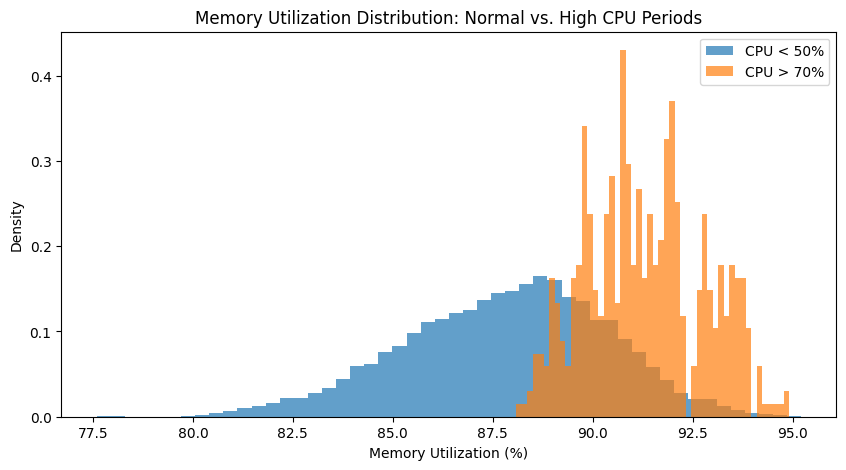

In [105]:
# Split data into "normal" (CPU < 50%) and "high CPU" (CPU > 70%)
normal_mem = df[df['cpu_util_percent'] < 50]['mem_util_percent']
high_cpu_mem = df[df['cpu_util_percent'] > 70]['mem_util_percent']

plt.figure(figsize=(10,5))
plt.hist(normal_mem, bins=50, alpha=0.7, label='CPU < 50%', density=True)
plt.hist(high_cpu_mem, bins=50, alpha=0.7, label='CPU > 70%', density=True)
plt.title('Memory Utilization Distribution: Normal vs. High CPU Periods')
plt.xlabel('Memory Utilization (%)')
plt.ylabel('Density')
plt.legend()
plt.show()

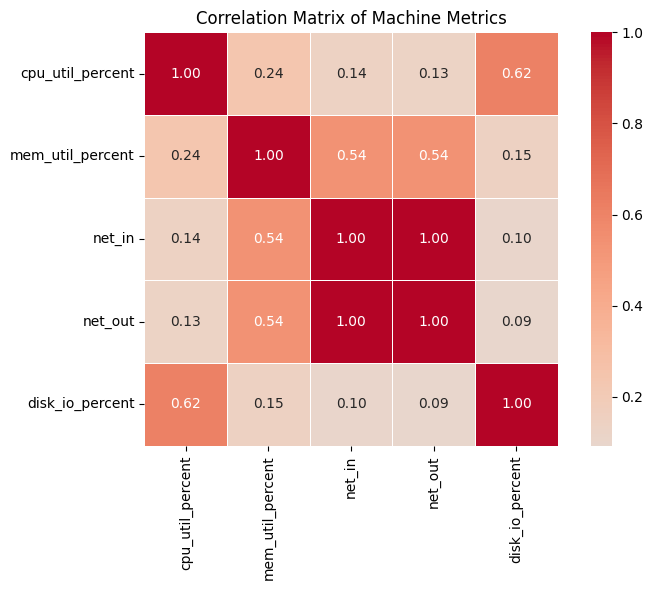

In [96]:
# Compute correlation on the numeric columns
corr = df[['cpu_util_percent', 'mem_util_percent', 'net_in', 'net_out', 'disk_io_percent']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', 
            square=True, linewidths=0.5)
plt.title('Correlation Matrix of Machine Metrics')
plt.tight_layout()
plt.show()

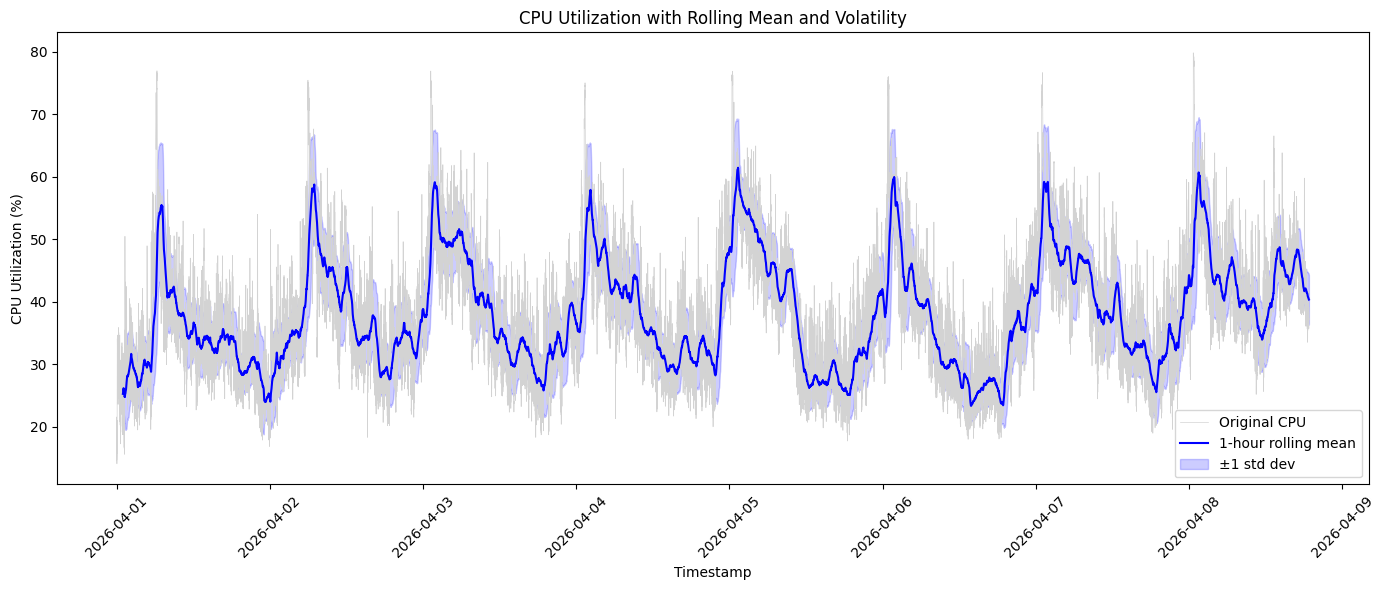

In [97]:
# Compute 1‑hour rolling average and standard deviation (360 intervals of 10 seconds)
window = 360  # 1 hour
df['cpu_rolling_mean'] = df['cpu_util_percent'].rolling(window=window).mean()
df['cpu_rolling_std'] = df['cpu_util_percent'].rolling(window=window).std()

plt.figure(figsize=(14,6))
plt.plot(df.index, df['cpu_util_percent'], color='lightgray', linewidth=0.5, label='Original CPU')
plt.plot(df.index, df['cpu_rolling_mean'], color='blue', linewidth=1.5, label='1‑hour rolling mean')
plt.fill_between(df.index, 
                 df['cpu_rolling_mean'] - df['cpu_rolling_std'],
                 df['cpu_rolling_mean'] + df['cpu_rolling_std'],
                 color='blue', alpha=0.2, label='±1 std dev')
plt.title('CPU Utilization with Rolling Mean and Volatility')
plt.xlabel('Timestamp')
plt.ylabel('CPU Utilization (%)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [98]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import pickle

# Use the existing DataFrame (df) from your notebook
# Make sure to drop any rows with NaN (if you created rolling windows)
feature_cols = ['cpu_util_percent', 'mem_util_percent', 'net_in', 'net_out', 'disk_io_percent']
df_clean = df[feature_cols].dropna().copy()

# Create label: 1 if CPU > 95% (anomaly), else 0
df_clean['anomaly'] = (df_clean['cpu_util_percent'] > 95).astype(int)

# Features and target
X = df_clean[feature_cols]
y = df_clean['anomaly']

# Train / test split (maintain time order)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

Training samples: 53793, Test samples: 13449


In [99]:
# Initialize Random Forest with 100 trees
rf_model = RandomForestClassifier(n_estimators=100,   # "epochs" in tree count
                                   random_state=42,
                                   n_jobs=-1)         # use all CPU cores

# Train the model
rf_model.fit(X_train, y_train)

# Evaluate on test set
y_pred = rf_model.predict(X_test)
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import pickle

# Prepare data (same as before)
feature_cols = ['cpu_util_percent', 'mem_util_percent', 'net_in', 'net_out', 'disk_io_percent']
df_clean = df[feature_cols].dropna().copy()
df_clean['anomaly'] = (df_clean['cpu_util_percent'] > 95).astype(int)

X = df_clean[feature_cols]
y = df_clean['anomaly']

# Scale features (important for neural networks)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train / test split
split = int(0.8 * len(X))
X_train, X_test = X_scaled[:split], X_scaled[split:]
y_train, y_test = y[:split], y[split:]

# Create MLP with 100 epochs and verbose output
mlp = MLPClassifier(hidden_layer_sizes=(64, 32),
                    activation='relu',
                    max_iter=100000,
                    tol=0,                    
                    n_iter_no_change=100000,      # wait 100000 epochs before stopping
                    verbose=True,
                    random_state=42)

mlp.fit(X_train, y_train)

# Evaluate
y_pred = mlp.predict(X_test)


# Save model and scaler
with open('mlp_anomaly_model.pkl', 'wb') as f:
    pickle.dump(mlp, f)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

Iteration 1, loss = 0.07805925
Iteration 2, loss = 0.00097451
Iteration 3, loss = 0.00030764
Iteration 4, loss = 0.00015436
Iteration 5, loss = 0.00009603
Iteration 6, loss = 0.00006803
Iteration 7, loss = 0.00005262
Iteration 8, loss = 0.00004331
Iteration 9, loss = 0.00003731
Iteration 10, loss = 0.00003325
Iteration 11, loss = 0.00003039
Iteration 12, loss = 0.00002831
Iteration 13, loss = 0.00002675
Iteration 14, loss = 0.00002556
Iteration 15, loss = 0.00002462
Iteration 16, loss = 0.00002385
Iteration 17, loss = 0.00002321
Iteration 18, loss = 0.00002266
Iteration 19, loss = 0.00002218
Iteration 20, loss = 0.00002173
Iteration 21, loss = 0.00002131
Iteration 22, loss = 0.00002090
Iteration 23, loss = 0.00002051
Iteration 24, loss = 0.00002010
Iteration 25, loss = 0.00001970
Iteration 26, loss = 0.00001928
Iteration 27, loss = 0.00001885
Iteration 28, loss = 0.00001841
Iteration 29, loss = 0.00001795
Iteration 30, loss = 0.00001747
Iteration 31, loss = 0.00001698
Iteration 32, los

In [100]:
import requests
import pandas as pd

def load_data_from_api(api_url):
    """
    Fetches data from a given API endpoint, processes it, and returns a pandas DataFrame.
    """
    try:
        response = requests.get(api_url)
        response.raise_for_status() # Raise an exception for HTTP errors
        data = response.json()
        
        # Extract records
        records = data.get('records', [])
        
        # Create DataFrame from records
        df = pd.DataFrame(records)
        
        # Convert timestamp to datetime and set as index
        if not df.empty:
            df['timestamp'] = pd.to_datetime(df['timestamp'])
            df.set_index('timestamp', inplace=True)
            
            # Drop the 'id' column as it's not needed for analysis
            if 'id' in df.columns:
                df.drop(columns=['id'], inplace=True)

            print("Data loaded successfully from API.")
            print("Shape:", df.shape)
            print("\nColumn names:", df.columns.tolist())
            print("\nFirst 5 rows:")
            print(df.head())
            return df
        else:
            print("No records found in the API response.")
            return pd.DataFrame() # Return an empty DataFrame
            
    except requests.exceptions.RequestException as e:
        print(f"Error fetching data from API: {e}")
        return pd.DataFrame() # Return an empty DataFrame
    except ValueError as e:
        print(f"Error parsing JSON response: {e}")
        return pd.DataFrame() # Return an empty DataFrame

# Example usage:
api_url = "http://13.50.208.58:5000/api/telemetry?per_page=200&sort_by=timestamp&sort_order=desc"
api_url = "http://13.62.95.174:5000/api/telemetry?per_page=200&sort_by=timestamp&sort_order=desc"
api_url = "http://13.62.215.163:5000/api/telemetry?per_page=200&sort_by=timestamp&sort_order=desc"
df = load_data_from_api(api_url)

KeyboardInterrupt: 

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import pickle

# Prepare data
feature_cols = ['cpu_util_percent', 'mem_util_percent', 'net_in', 'net_out', 'disk_io_percent']
df_clean = df[feature_cols].dropna().copy()
df_clean['anomaly'] = (df_clean['cpu_util_percent'] > 95).astype(int)

X = df_clean[feature_cols]
y = df_clean['anomaly']

# Scale features (important for neural networks)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train / test split
split = int(0.8 * len(X))
X_train, X_test = X_scaled[:split], X_scaled[split:]
y_train, y_test = y[:split], y[split:]

# Create MLP with 100 epochs and verbose output
mlp = MLPClassifier(hidden_layer_sizes=(64, 32),
                    activation='relu',
                    max_iter=100000,
                    tol=0,
                    n_iter_no_change=100000,      # wait 100000 epochs before stopping
                    verbose=True,
                    random_state=42)

mlp.fit(X_train, y_train)

# Evaluate
y_pred = mlp.predict(X_test)

# Save model and scaler
with open('mlp_anomaly_model.pkl', 'wb') as f:
    pickle.dump(mlp, f)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

In [ ]:
with open('random_forest_anomaly.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

In [ ]:
calculate_accuracy_recall()